# Benchmarking result analysis

## Preparation

In [1]:
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from scipy.stats import binomtest, wilcoxon, ecdf

In [4]:
from matplotlib.ticker import ScalarFormatter, FuncFormatter

In [5]:
plt.rcParams['svg.fonttype'] = 'none'

In [6]:
outdir = 'plots'

In [7]:
Path(outdir).mkdir(parents=True, exist_ok=True)

In [8]:
def to_k(n):
    """Convert numbers like 50000 into 50k."""
    n = str(n)
    if n.endswith('000'):
        n = n[:-3] + 'k'
    return n

## Data

### scikit-bio result

In [9]:
df_skbio = pd.read_table('skbio/calc.tsv', names=['samples', 'seed', 'threads', 'runtime']).groupby(
    ['samples', 'seed', 'threads']).median().reset_index().drop(columns='seed')
df_skbio.head()

,samples,threads,runtime
0,10,1,0.000212
1,10,2,0.000227
2,10,3,0.000226
3,10,4,0.000223
4,10,6,0.000229


In [10]:
dfm_skbio = df_skbio.groupby(['samples', 'threads']).agg(mean=('runtime', 'mean'), std=('runtime', 'std')).reset_index()
dfm_skbio.head()

,samples,threads,mean,std
0,10,1,0.000213,2.949576e-06
1,10,2,0.000225,1.673320e-06
2,10,3,0.000225,7.071068e-07
3,10,4,0.000224,3.847077e-06
4,10,6,0.000226,2.828427e-06


### FastME results

In [11]:
df_fastme = pd.read_table('fastme/calc.tsv', names=['samples', 'seed', 'rep', 'runtime']).drop(
    columns='rep').groupby(['samples', 'seed']).median().reset_index().drop(columns='seed')
df_fastme.head()

,samples,runtime
0,10,0.000013
1,10,0.000016
2,10,0.000020
3,10,0.000017
4,10,0.000015


In [12]:
dfm_fastme = df_fastme.groupby('samples').agg(mean=('runtime', 'mean'), std=('runtime', 'std')).reset_index()
dfm_fastme.head()

,samples,mean,std
0,10,0.000016,0.000003
1,20,0.000044,0.000002
2,50,0.000270,0.000016
3,100,0.001364,0.000044
4,200,0.006693,0.000136


### NJ results

In [13]:
df_nj = pd.read_table('nj/calc.tsv', names=['samples', 'seed', 'threads', 'rep', 'runtime']).drop(
    columns='rep').groupby(['samples', 'seed', 'threads']).median().reset_index().drop(columns='seed')
df_nj.head()

,samples,threads,runtime
0,10,1,0.000105
1,10,8,0.000471
2,10,32,0.000669
3,10,1,0.000110
4,10,8,0.000455


In [14]:
dfm_nj = df_nj.groupby(['samples', 'threads']).agg(mean=('runtime', 'mean'), std=('runtime', 'std')).reset_index()
dfm_nj.head()

,samples,threads,mean,std
0,10,1,0.000103,0.000006
1,10,8,0.000570,0.000104
2,10,32,0.000985,0.000249
3,20,1,0.000207,0.000018
4,20,8,0.000975,0.000295


## Runtime

In [15]:
threads = (1, 8, 32)

In [16]:
cmap = plt.get_cmap('tab20c')

In [17]:
samples = df_skbio['samples'].unique()
samples

array([    10,     20,     50,    100,    200,    500,   1000,   2000,
         5000,  10000,  20000,  50000, 100000, 200000])

### Spectrum

In [18]:
margs = dict(marker='o', ms=5)

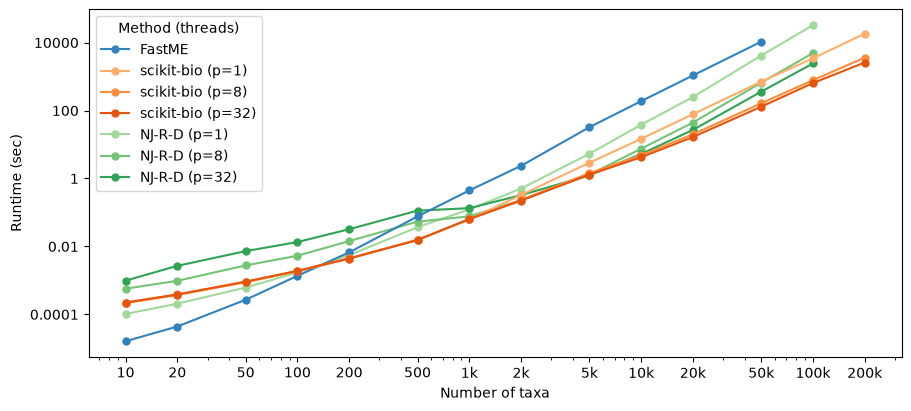

In [19]:
plt.figure(figsize=(9, 4), constrained_layout=True)

# NJ
method = 'NJ-R-D'
for i, thread in enumerate(threads):
    plt.plot('samples', 'mean', data=dfm_nj.query(f'threads == {thread}'),
             color=cmap(10 - i), label=f'{method} (p={thread})', **margs)

# FastME
plt.plot('samples', 'mean', data=dfm_fastme, color=cmap(0), label='FastME', **margs)

# scikit-bio
method = 'scikit-bio'
for i, thread in enumerate(threads):
    plt.plot('samples', 'mean', data=dfm_skbio.query(f'threads == {thread}'),
             color=cmap(6 - i), label=f'{method} (p={thread})', **margs)

handles, labels = plt.gca().get_legend_handles_labels()
handles = handles[3:4] + handles[4:] + handles[:3]
labels = labels[3:4] + labels[4:] + labels[:3]

plt.legend(handles, labels, title='Method (threads)')

plt.xscale('log')

plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.xticks(samples, [to_k(x) for x in samples])
plt.xlabel('Number of taxa')

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:g}'))
plt.ylabel('Runtime (sec)')

plt.savefig(f'{outdir}/runtime.svg')

### Large samples

In [20]:
samples = (10000, 20000, 50000)

In [21]:
margs = dict(marker='o', ms=5, mec='none', ls='none')

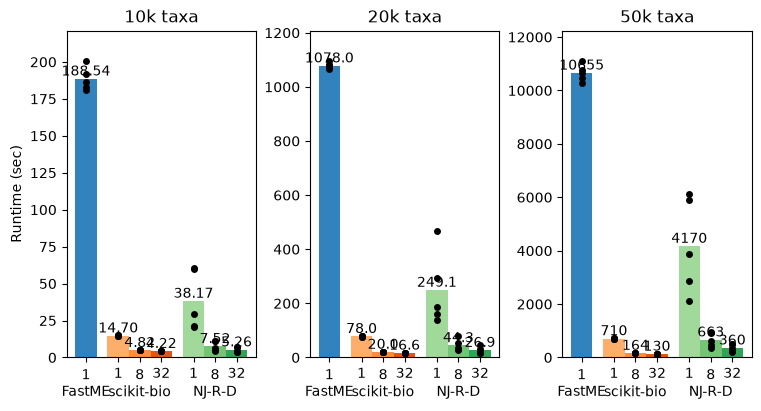

In [22]:
plt.figure(figsize=(7.5, 4), constrained_layout=True)
for i, sample in enumerate(samples):
    plt.subplot(1, len(samples), i + 1)
    poses, ticks = [], []
    fmt = '{:.' + str(2 - i) + 'f}'

    # FastME
    color = cmap(0)
    poses.append(pos := 0)
    ticks.append('1\nFastME')
    vals = df_fastme.query(f'samples == {sample}')['runtime']
    plt.bar(pos, mval := vals.mean(), width=0.6, color=color)
    plt.plot((pos,) * len(vals), vals, color='k', **margs)
    plt.text(pos, mval, fmt.format(mval), ha='center', va='bottom')

    # scikit-bio
    rows = df_skbio.query(f'samples == {sample}')
    for j, thread in enumerate(threads):
        poses.append(pos := 0.9 + j * 0.6)
        ticks.append(f'{thread}\nscikit-bio' if thread == 8 else str(thread))
        color = cmap(6 - j)
        vals = rows.query(f'threads == {thread}')['runtime']
        plt.bar(pos, mval := vals.mean(), width=0.6, color=color)
        plt.plot((pos,) * len(vals), vals, color='k', **margs)
        plt.text(pos, mval, fmt.format(mval), ha='center', va='bottom')

    # NJ
    rows = df_nj.query(f'samples == {sample}')
    for j, thread in enumerate(threads):
        poses.append(pos := 3 + j * 0.6)
        ticks.append(f'{thread}\nNJ-R-D' if thread == 8 else str(thread))
        color = cmap(10 - j)
        vals = rows.query(f'threads == {thread}')['runtime']
        plt.bar(pos, mval := vals.mean(), width=0.6, color=color)
        plt.plot((pos,) * len(vals), vals, color='k', **margs)
        plt.text(pos, mval, fmt.format(mval), ha='center', va='bottom')

    plt.xticks(poses, ticks)

    ytop = plt.ylim()[1]
    plt.ylim(bottom=0, top=ytop * 1.05)
    if i == 0:
        plt.ylabel('Runtime (sec)')
    plt.title(f'{to_k(sample)} taxa')
plt.savefig(f'{outdir}/bigtime.svg')

In [23]:
(dfm_skbio.query('samples == 50000')['mean'].min() / 60).item()

2.1631610466666666

In [24]:
(dfm_fastme.query('samples == 50000')['mean'] / 3600).item()

2.9597665672777778

In [25]:
(dfm_skbio.query('samples == 100000')['mean'].min() / 60).item()

10.580484353333333

In [26]:
(dfm_skbio.query('samples == 100000')['mean'].min() / 3600).item()

0.17634140588888889

In [27]:
(dfm_skbio.query('samples == 200000')['mean'].min() / 60).item()

43.2455565

In [28]:
(dfm_skbio.query('samples == 200000')['mean'].min() / 3600).item()

0.7207592749999999

In [29]:
dfm_nj.query('samples == 50000 & threads == 8')['mean']

34    662.6106
Name: mean, dtype: float64

In [30]:
for thread in (1, 8, 32):
    print(thread, dfm_nj.query(f'samples == 50000 & threads == {thread}')['mean'].iloc[0] /
          dfm_skbio.query(f'samples == 50000 & threads == {thread}')['mean'].iloc[0])

1 5.874422962362164
8 4.049045210815342
32 2.7744237724048015


## Parallelization

### Speed-up

In [31]:
min_samples = 1000

In [32]:
dfm = dfm_skbio.query(f'samples >= {min_samples} & samples <= 100000').pivot(columns='samples', index='threads', values='mean')
dfm

samples,1000,2000,5000,10000,20000,50000,100000
threads,,,,,,,
1,0.062725,0.326528,2.910333,14.695887,78.044776,709.871936,3441.361425
2,0.071077,0.301054,2.187783,9.407379,45.578339,394.170608,1886.489355
3,0.068741,0.277065,1.871808,7.409729,34.220035,290.059586,1383.305549
4,0.066799,0.262219,1.698136,6.349849,28.446642,238.532568,1136.421710
6,0.064202,0.244390,1.519345,5.326185,22.757542,187.711127,895.376524
8,0.062574,0.233989,1.432933,4.821557,20.011993,163.646135,785.732584
12,0.061044,0.222493,1.352164,4.350976,17.613613,142.050340,683.611325
16,0.060694,0.218768,1.323275,4.215099,16.743408,134.449092,646.336869
24,0.061756,0.218388,1.303775,4.174622,16.398597,129.789663,634.829061


In [33]:
dfs = dfm.iloc[0] / dfm
dfs

samples,1000,2000,5000,10000,20000,50000,100000
threads,,,,,,,
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.882504,1.084616,1.330266,1.562166,1.712322,1.800926,1.824215
3,0.912494,1.178525,1.554824,1.983323,2.280675,2.447331,2.487781
4,0.939023,1.245251,1.713840,2.314368,2.743550,2.975996,3.028243
6,0.976995,1.336092,1.915518,2.759177,3.429403,3.781725,3.843480
8,1.002426,1.395484,2.031032,3.047954,3.899900,4.337847,4.379813
12,1.027537,1.467585,2.152352,3.377607,4.430935,4.997327,5.034091
16,1.033470,1.492574,2.199341,3.486487,4.661224,5.279857,5.324408
24,1.015694,1.495174,2.232236,3.520292,4.759235,5.469403,5.420926


In [34]:
cmap = plt.cm.viridis

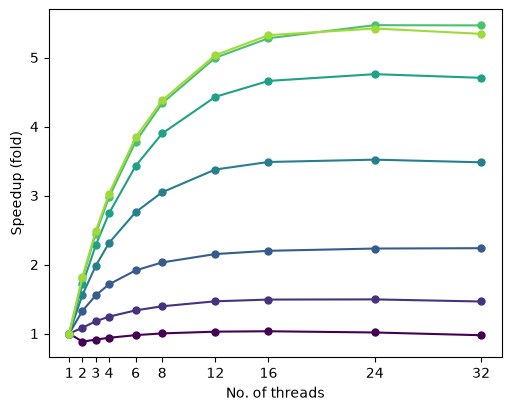

In [35]:
plt.figure(figsize=(5, 4), constrained_layout=True)
for i, (sample, data) in enumerate(dfs.items()):
    plt.plot(data, label=sample // 1000, marker='o', ms=5, color=cmap(i / dfs.shape[1]))
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles[::-1], labels[::-1], title='# taxa (k)')
plt.xticks(dfs.index)
plt.xlabel('No. of threads')
plt.ylabel('Speedup (fold)')
plt.savefig(f'{outdir}/speedup.svg')

### Parallel efficiency

In [36]:
dfe = dfs.div(dfs.index, axis=0)
dfe

samples,1000,2000,5000,10000,20000,50000,100000
threads,,,,,,,
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.441252,0.542308,0.665133,0.781083,0.856161,0.900463,0.912107
3,0.304165,0.392842,0.518275,0.661108,0.760225,0.815777,0.829260
4,0.234756,0.311313,0.428460,0.578592,0.685887,0.743999,0.757061
6,0.162832,0.222682,0.319253,0.459863,0.571567,0.630288,0.640580
8,0.125303,0.174436,0.253879,0.380994,0.487488,0.542231,0.547477
12,0.085628,0.122299,0.179363,0.281467,0.369245,0.416444,0.419508
16,0.064592,0.093286,0.137459,0.217905,0.291327,0.329991,0.332776
24,0.042321,0.062299,0.093010,0.146679,0.198301,0.227892,0.225872


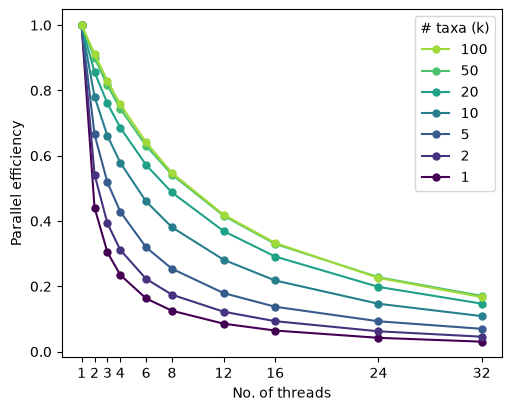

In [37]:
plt.figure(figsize=(5, 4), constrained_layout=True)
for i, (sample, data) in enumerate(dfe.items()):
    plt.plot(data, label=sample // 1000, marker='o', ms=5, color=cmap(i / dfs.shape[1]))
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], title='# taxa (k)')
plt.xticks(dfs.index)
plt.xlabel('No. of threads')
plt.ylabel('Parallel efficiency')
plt.savefig(f'{outdir}/efficiency.svg')

### Practical threads

In [38]:
max_speedup = dfs.max().rename('Max. speed-up')
max_speedup

samples
1000      1.033470
2000      1.495174
5000      2.237199
10000     3.520292
20000     4.759235
50000     5.469403
100000    5.420926
Name: Max. speed-up, dtype: float64

In [39]:
max_threads = dfs.idxmax().rename('Max. threads')
max_threads

samples
1000      16
2000      24
5000      32
10000     24
20000     24
50000     24
100000    24
Name: Max. threads, dtype: int64

In [40]:
serial_times = dfm.iloc[0].rename('Serial runtime')
serial_times

samples
1000         0.062725
2000         0.326528
5000         2.910333
10000       14.695887
20000       78.044776
50000      709.871936
100000    3441.361425
Name: Serial runtime, dtype: float64

In [41]:
best_times = dfm.min().rename('Best runtime')
best_times

samples
1000        0.060694
2000        0.218388
5000        1.300882
10000       4.174622
20000      16.398597
50000     129.789663
100000    634.829061
Name: Best runtime, dtype: float64

In [42]:
fastme_times = dfm_fastme.set_index('samples').loc[dfs.columns[:-1], 'mean']
fastme_times

samples
1000         0.444859
2000         2.355954
5000        32.342386
10000      188.543454
20000     1077.998037
50000    10655.159642
Name: mean, dtype: float64

In [43]:
serial_vs_fastme = (fastme_times / serial_times).rename('Serial vs. FastME')
serial_vs_fastme

samples
1000       7.092160
2000       7.215166
5000      11.112950
10000     12.829675
20000     13.812559
50000     15.009974
100000          NaN
Name: Serial vs. FastME, dtype: float64

In [44]:
best_vs_fastme = (fastme_times / best_times).rename('Best vs. FastME')
best_vs_fastme

samples
1000       7.329532
2000      10.787927
5000      24.861886
10000     45.164200
20000     65.737211
50000     82.095595
100000          NaN
Name: Best vs. FastME, dtype: float64

practical optimal thread count (smallest thread count whose speedup is within 5% of the best speedup)

In [45]:
th = 0.95

In [46]:
practical_threads = (dfs > max_speedup * th).idxmax().rename('Practical threads')
practical_threads

samples
1000       1
2000      12
5000      12
10000     12
20000     16
50000     16
100000    16
Name: Practical threads, dtype: int64

In [47]:
df_summary = pd.concat((
    serial_times, serial_vs_fastme, best_times, best_vs_fastme, max_speedup, max_threads, practical_threads
), axis=1)
df_summary

,Serial runtime,Serial vs. FastME,Best runtime,Best vs. FastME,Max. speed-up,Max. threads,Practical threads
samples,,,,,,,
1000,0.062725,7.092160,0.060694,7.329532,1.033470,16,1
2000,0.326528,7.215166,0.218388,10.787927,1.495174,24,12
5000,2.910333,11.112950,1.300882,24.861886,2.237199,32,12
10000,14.695887,12.829675,4.174622,45.164200,3.520292,24,12
20000,78.044776,13.812559,16.398597,65.737211,4.759235,24,16
50000,709.871936,15.009974,129.789663,82.095595,5.469403,24,16
100000,3441.361425,NaN,634.829061,NaN,5.420926,24,16


In [48]:
df_summary.to_csv(f'{outdir}/summary.tsv', sep='\t')

## Memory

scikit-bio

In [49]:
df_skbio_read = pd.read_table('skbio/read.tsv', names=['samples', 'seed', 'reps', 'runtime', 'memory'])[
    ['samples', 'seed', 'memory']].groupby(['samples', 'seed']).median().rename(columns={'memory': 'read'})
df_skbio_full = pd.read_table('skbio/full.tsv', names=['samples', 'seed', 'threads', 'reps', 'runtime', 'memory'])[
    ['samples', 'seed', 'threads', 'memory']].groupby(['samples', 'seed', 'threads']).median().rename(columns={'memory': 'full'})

In [50]:
df_skbio_mem = pd.concat((df_skbio_full, df_skbio_read.reindex(df_skbio_full.index)), axis=1) / 1024 / 1024
df_skbio_mem['calc'] = df_skbio_mem['full'] - df_skbio_mem['read']
df_skbio_mem = df_skbio_mem.reset_index().groupby(['samples', 'threads']).agg(
    full_mean=('full', 'mean'), full_std=('full', 'std'),
    read_mean=('read', 'mean'), read_std=('read', 'std'),
    calc_mean=('calc', 'mean'), calc_std=('calc', 'std'))
df_skbio_mem

full_mean  full_std   read_mean  read_std    calc_mean  \
samples threads                                                             
10      1           0.193765  0.000715    0.156606  0.000213     0.037159   
        2           0.194137  0.000437    0.156606  0.000213     0.037531   
        3           0.194338  0.000507    0.156606  0.000213     0.037732   
        4           0.193913  0.000547    0.156606  0.000213     0.037306   
        6           0.194044  0.000641    0.156606  0.000213     0.037437   
...                      ...       ...         ...       ...          ...   
100000  24        372.707545  0.030484   74.688183  0.000711   298.019361   
        32        372.705565  0.034648   74.688183  0.000711   298.017382   
200000  1        1490.320126       NaN  298.216244       NaN  1192.103882   
        8        1490.320019       NaN  298.216244       NaN  1192.103775   
        32       1490.319370       NaN  298.216244       NaN  1192.103127   

                 calc_std  
samples threads            
10      1        0.000538  
        2        0.000347  
        3        0.000683  
        4        0.000575  
        6        0.000642  
...                   ...  
100000  24       0.030406  
        32       0.034571  
200000  1             NaN  
        8             NaN  
        32            NaN  

[133 rows x 6 columns]

FastMe

In [51]:
df_fastme_read = pd.read_table('fastme/read.tsv', names=['samples', 'seed', 'reps', 'runtime', 'memory'])[
    ['samples', 'seed', 'memory']].groupby(['samples', 'seed']).median().rename(columns={'memory': 'read'})
df_fastme_full = pd.read_table('fastme/full.tsv', names=['samples', 'seed', 'reps', 'runtime', 'memory'])[
    ['samples', 'seed', 'memory']].groupby(['samples', 'seed']).median().rename(columns={'memory': 'full'})

In [52]:
df_fastme_mem = pd.concat((df_fastme_full, df_fastme_read), axis=1) / 1024 / 1024
df_fastme_mem['calc'] = df_fastme_mem['full'] - df_fastme_mem['read']
df_fastme_mem = df_fastme_mem.reset_index().groupby('samples').agg(
    full_mean=('full', 'mean'), full_std=('full', 'std'),
    read_mean=('read', 'mean'), read_std=('read', 'std'),
    calc_mean=('calc', 'mean'), calc_std=('calc', 'std'))
df_fastme_mem

,full_mean,full_std,read_mean,read_std,calc_mean,calc_std
samples,,,,,,
10,0.001953,0.000000,0.001953,0.000000,0.000000,0.000000
20,0.001953,0.000000,0.001953,0.000000,0.000000,0.000000
50,0.001953,0.000000,0.001953,0.000000,0.000000,0.000000
100,0.001953,0.000000,0.001953,0.000000,0.000000,0.000000
200,0.003906,0.000000,0.001953,0.000000,0.001953,0.000000
500,0.014648,0.000000,0.005859,0.000000,0.008789,0.000000
1000,0.054688,0.000000,0.016602,0.000000,0.038086,0.000000
2000,0.210938,0.000000,0.061523,0.000000,0.149414,0.000000
5000,1.306641,0.000000,0.373047,0.000000,0.933594,0.000000


NJ

In [53]:
df_nj_mem = pd.read_table('nj/full.tsv', names=['samples', 'seed', 'threads', 'reps', 'runtime', 'memory'])[
    ['samples', 'seed', 'threads', 'memory']].groupby(['samples', 'seed', 'threads']).median().reset_index().groupby(
        ['samples', 'threads']).agg(full_mean=('memory', 'mean'), full_std=('memory', 'std'))  / 1024 / 1024
df_nj_mem.head()

full_mean  full_std
samples threads                     
10      1          0.00293       0.0
        8          0.00293       0.0
        32         0.00293       0.0
20      1          0.00293       0.0
        8          0.00293       0.0

In [54]:
df_skbio_mem

full_mean  full_std   read_mean  read_std    calc_mean  \
samples threads                                                             
10      1           0.193765  0.000715    0.156606  0.000213     0.037159   
        2           0.194137  0.000437    0.156606  0.000213     0.037531   
        3           0.194338  0.000507    0.156606  0.000213     0.037732   
        4           0.193913  0.000547    0.156606  0.000213     0.037306   
        6           0.194044  0.000641    0.156606  0.000213     0.037437   
...                      ...       ...         ...       ...          ...   
100000  24        372.707545  0.030484   74.688183  0.000711   298.019361   
        32        372.705565  0.034648   74.688183  0.000711   298.017382   
200000  1        1490.320126       NaN  298.216244       NaN  1192.103882   
        8        1490.320019       NaN  298.216244       NaN  1192.103775   
        32       1490.319370       NaN  298.216244       NaN  1192.103127   

                 calc_std  
samples threads            
10      1        0.000538  
        2        0.000347  
        3        0.000683  
        4        0.000575  
        6        0.000642  
...                   ...  
100000  24       0.030406  
        32       0.034571  
200000  1             NaN  
        8             NaN  
        32            NaN  

[133 rows x 6 columns]

In [55]:
df_fastme_mem['read_mean'].iloc[0] * 1024

np.float64(2.0)

In [56]:
df_skbio_mem['read_mean'].iloc[0] * 1024

np.float64(160.36484375)

In [57]:
df_nj_mem['full_mean'].iloc[0] * 1024

np.float64(3.0)

In [58]:
1.0 / (df_fastme_mem.query('samples >= 5000')['full_mean'] / df_skbio_mem.query(
    'threads == 1 & samples >= 5000 & samples <= 50000')['full_mean'])

samples  threads
5000     1          0.853068
10000    1          0.746418
20000    1          0.721021
50000    1          0.716710
Name: full_mean, dtype: float64

In [59]:
1.0 / (df_fastme_mem.query('samples >= 5000')['calc_mean'] / df_skbio_mem.query(
    'threads == 1 & samples >= 5000 & samples <= 50000')['calc_mean'])

samples  threads
5000     1          0.525597
10000    1          0.500313
20000    1          0.499977
50000    1          0.499983
Name: calc_mean, dtype: float64

In [60]:
df_nj_mem.query('threads == 1 & samples >= 5000')['full_mean'] / df_skbio_mem.query(
    'threads == 1 & samples >= 5000 & samples <= 50000')['full_mean']

samples  threads
5000     1          0.755910
10000    1          0.863604
20000    1          0.890639
50000    1          0.898543
100000   1               NaN
Name: full_mean, dtype: float64

In [61]:
cmap = plt.get_cmap('tab20c')

In [62]:
margs = dict(marker='o', ms=5)

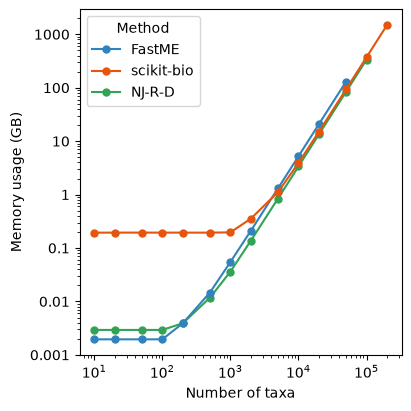

In [63]:
plt.figure(figsize=(4, 4), constrained_layout=True)
plt.plot('samples', 'full_mean', data=df_nj_mem.query('threads == 1').reset_index(), color=cmap(8), label='NJ-R-D', **margs)
plt.plot('samples', 'full_mean', data=df_fastme_mem.reset_index(), color=cmap(0), label='FastME', **margs)
plt.plot('samples', 'full_mean', data=df_skbio_mem.query('threads == 1').reset_index(), color=cmap(4), label='scikit-bio', **margs)
handles, labels = plt.gca().get_legend_handles_labels()
handles = [handles[1], handles[2], handles[0]]
labels = [labels[1], labels[2], labels[0]]
plt.legend(handles, labels, title='Method')

plt.xscale('log')
# plt.xticks(samples)
plt.xlabel('Number of taxa')

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:g}'))
plt.ylabel('Memory usage (GB)');
plt.savefig(f'{outdir}/memory.svg')

In [64]:
threads = (1, 8)

In [65]:
samples = (10000, 20000, 50000)

In [66]:
margs = dict(marker='o', ms=5, mec='none', ls='none')

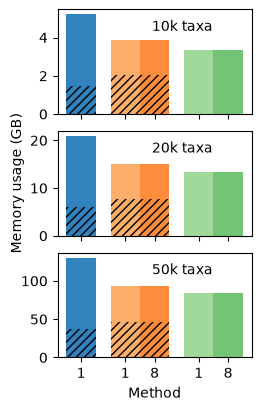

In [67]:
plt.figure(figsize=(2.5, 4), constrained_layout=True)
for i, sample in enumerate(samples):
    plt.subplot(len(samples), 1, i + 1)
    poses, ticks = [], []
    fmt = '{:.' + str(2 - i) + 'f}'

    # FastME
    color = cmap(0)
    poses.append(pos := 0)
    ticks.append('1')
    row = df_fastme_mem.loc[sample]
    plt.bar(pos, mval := row['read_mean'], width=0.6, color=color, hatch='////')
    plt.bar(pos, row['calc_mean'], bottom=mval, width=0.6, color=color)

    # scikit-bio
    rows = df_skbio_mem.loc[(sample,)]
    for j, thread in enumerate(threads):
        poses.append(pos := 0.9 + j * 0.6)
        ticks.append(str(thread))
        color = cmap(6 - j)
        row = rows.loc[thread]
        plt.bar(pos, mval := row['read_mean'], width=0.6, color=color, hatch='////')
        plt.bar(pos, row['calc_mean'], bottom=mval, width=0.6, color=color)

    # NJ
    rows = df_nj_mem.loc[(sample,)]
    for j, thread in enumerate(threads):
        poses.append(pos := 2.4 + j * 0.6)
        ticks.append(str(thread))
        color = cmap(10 - j)
        row = rows.loc[thread]
        plt.bar(pos, row['full_mean'], width=0.6, color=color)

    if i < 2:
        plt.xticks(poses, [])
    else:
        plt.xticks(poses, ticks)
        plt.xlabel('Method')
    if i == 1:
        plt.ylabel('Memory usage (GB)')

    plt.text(0.8, 0.9, f'{to_k(sample)} taxa', transform=plt.gca().transAxes, ha='right', va='top')

    # plt.title(f'{sample} taxa')
plt.savefig(f'{outdir}/bigmem.svg')

## Loss

In [68]:
df_loss = pd.concat((pd.read_table(f'loss/{key}.loss', names=['samples', 'seed', key], index_col=(0, 1))
                     for key in ('fastme', 'skbio', 'nj')), axis=1)
df_loss.head()

fastme     skbio        nj
samples seed                              
10      0     1.375170  1.375170  1.375415
        1     1.343864  1.343864  1.342442
        2     1.488464  1.488464  1.482989
        3     1.035769  1.035769  1.034509
        4     1.352408  1.352408  1.352408

In [69]:
for key in ('skbio', 'nj'):
    df_loss[f'{key}_frac'] = df_loss[key] / df_loss['fastme']

In [70]:
df_loss.head()

fastme     skbio        nj  skbio_frac   nj_frac
samples seed                                                    
10      0     1.375170  1.375170  1.375415         1.0  1.000178
        1     1.343864  1.343864  1.342442         1.0  0.998942
        2     1.488464  1.488464  1.482989         1.0  0.996322
        3     1.035769  1.035769  1.034509         1.0  0.998783
        4     1.352408  1.352408  1.352408         1.0  1.000000

In [71]:
df_loss['skbio_frac'].describe()

count    6.000000e+01
mean     1.000000e+00
std      1.525636e-08
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: skbio_frac, dtype: float64

In [72]:
df_loss.groupby('samples')['skbio_frac'].mean().describe()

count    1.200000e+01
mean     1.000000e+00
std      6.811695e-09
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: skbio_frac, dtype: float64

In [73]:
df_loss.groupby('samples')['nj_frac'].describe()[['mean', 'std']] * 100

,mean,std
samples,,
10,99.884494,0.154043
20,99.859000,0.085141
50,99.694811,0.214986
100,99.829513,0.249751
200,100.220854,0.276660
500,100.428743,0.296103
1000,100.660152,0.253079
2000,100.714954,0.135805
5000,100.878748,0.095875


In [74]:
(1.0 - df_loss.query('samples <= 100')['nj_frac']).describe()[['mean', 'std']] * 100

mean    0.183045
std     0.187128
Name: nj_frac, dtype: float64

In [75]:
(df_loss['nj_frac'] - 1.0).groupby('samples').describe()[['mean', 'std']] * 100

,mean,std
samples,,
10,-0.115506,0.154043
20,-0.141000,0.085141
50,-0.305189,0.214986
100,-0.170487,0.249751
200,0.220854,0.276660
500,0.428743,0.296103
1000,0.660152,0.253079
2000,0.714954,0.135805
5000,0.878748,0.095875


In [76]:
grouped = df_loss.groupby('samples')

In [77]:
margs = dict(marker='o', ms=5, mec='none', ls='none')

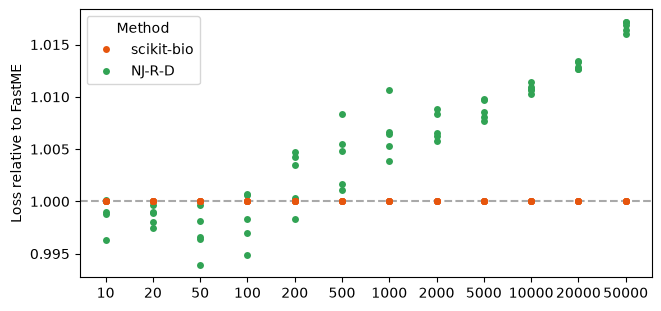

In [78]:
plt.figure(figsize=(6.5, 3), constrained_layout=True)
plt.axhline(1.0, color='darkgrey', ls='--')
for i, (sample, group) in enumerate(grouped):
    plt.plot([i] * 5, group['nj_frac'], color=cmap(8), label='NJ-R-D' if i == 0 else None, **margs)
    plt.plot([i] * 5, group['skbio_frac'], color=cmap(4), label='scikit-bio' if i == 0 else None, **margs)
handles, labels = plt.gca().get_legend_handles_labels()
handles = handles[1:] + handles[:1]
labels = labels[1:] + labels[:1]
plt.legend(handles, labels, title='Method')
plt.xticks(range(len(grouped)), grouped.groups.keys())
plt.ylabel('Loss relative to FastME')
plt.savefig(f'{outdir}/relative.svg')

## Consistency

In [79]:
places = 8

In [80]:
keys = ('1k', '10k')

In [81]:
dfs = {}
for key in keys:
    df = pd.read_table(f'consi/{key}.tsv', names=['skbio', 'fastme', 'RF'])
    for method in ('skbio', 'fastme'):
        df[method] = df[method].round(places)
    dfs[key] = df

### Scatter plot

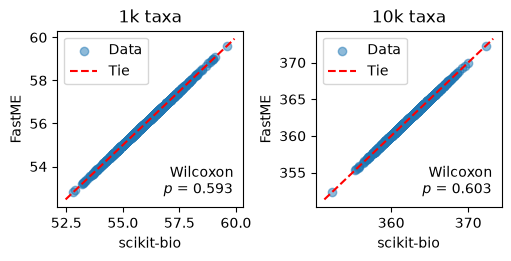

In [82]:
plt.figure(figsize=(5, 2.5), constrained_layout=True)
for i, key in enumerate(keys):
    plt.subplot(1, len(keys), i + 1)
    skbio = dfs[key]['skbio'].to_numpy()
    fastme = dfs[key]['fastme'].to_numpy()

    plt.scatter(skbio, fastme, alpha=0.5, label='Data')

    xmin, xmax = plt.xlim()
    ymin, ymax = plt.ylim()
    min2 = min(xmin, ymin)
    max2 = max(xmax, ymax)
    plt.plot((min2, max2), (min2, max2), color='red', ls='--', label='Tie')

    # Wilcoxon signed-rank test
    wilc = wilcoxon(skbio, fastme)
    plt.text(0.95, 0.05, f'Wilcoxon\n$p$ = {wilc.pvalue:.3f}',
             transform=plt.gca().transAxes, ha='right', va='bottom')

    plt.legend()
    plt.xlabel('scikit-bio')
    plt.ylabel('FastME')

    # plt.grid(True, ls='--')
    plt.title(f'{key} taxa')
plt.savefig(f'plots/scatter.svg')

### ECDF

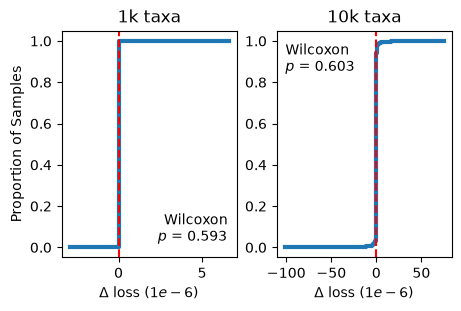

In [83]:
plt.figure(figsize=(4.5, 3), constrained_layout=True)
for i, key in enumerate(keys):
    plt.subplot(1, len(keys), i + 1)
    skbio = dfs[key]['skbio'].to_numpy()
    fastme = dfs[key]['fastme'].to_numpy()

    res = ecdf((skbio - fastme) * 1e6)
    plt.plot(res.sf.quantiles, res.cdf.probabilities, drawstyle='steps-post', label='ECDF', lw=3)
    plt.axvline(x=0, color='red', ls='--', label='Tie')

    # Wilcoxon signed-rank test
    wilc = wilcoxon(skbio, fastme)
    text = f'Wilcoxon\n$p$ = {wilc.pvalue:.3f}'
    if i == 0:
        plt.text(0.95, 0.05, text, transform=plt.gca().transAxes, ha='right', va='bottom')
    else:
        plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, ha='left', va='top')

    plt.xlabel(r'$\Delta$ loss ($1e-6$)')
    if i == 0:
        plt.ylabel('Proportion of Samples')

    # plt.grid(True, ls='--')
    plt.title(f'{key} taxa')
plt.savefig(f'plots/ecdf.svg')

### Categories

In [84]:
labels = ['Identical', 'Equally\ngood', 'scikit-bio\nbetter', 'FastME\nbetter']

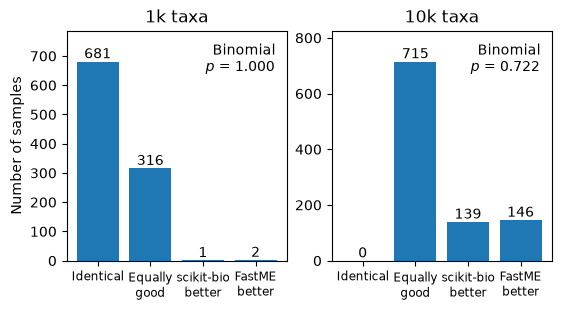

In [85]:
plt.figure(figsize=(5.5, 3), constrained_layout=True)
for i, key in enumerate(keys):
    plt.subplot(1, len(keys), i + 1)
    df = dfs[key]
    n_same = df.query('RF == 0').shape[0]
    n_equal = df.query('skbio == fastme').shape[0] - n_same
    n_better = df.query('skbio < fastme').shape[0]
    n_worse = df.query('skbio > fastme').shape[0]
    data = np.array([n_same, n_equal, n_better, n_worse])
    
    plt.bar(range(4), data)
    ytop = plt.ylim()[1]
    plt.ylim(top=ytop * 1.1)
    for j, datum in enumerate(data):
        plt.text(j, datum, datum, ha='center', va='bottom')
    plt.xticks(range(4), labels, fontsize='small')

    # Binomial test
    bino = binomtest(n_better, n_better + n_worse, p=0.5, alternative='two-sided')
    plt.text(0.95, 0.95, f'Binomial\n$p$ = {bino.pvalue:.3f}',
             transform=plt.gca().transAxes, ha='right', va='top')

    if i == 0:
        plt.ylabel('Number of samples')
    plt.title(f'{key} taxa')
plt.savefig(f'plots/category.svg')